# EDA: Heart Disease Playground

Purpose: move through the requested plan Phases 1-4 via the shortest path.
Target data: `data/raw/train.csv`, `data/raw/test.csv`, `data/raw/sample_submission.csv`


### Package import

In [1]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Prefer Kaggle input paths if available; fallback to local data/raw.
kaggle_dir = Path("/kaggle/input/playground-series-s6e2")
if kaggle_dir.exists():
    train = pd.read_csv(kaggle_dir / "train.csv")
    test = pd.read_csv(kaggle_dir / "test.csv")
    sub = pd.read_csv(kaggle_dir / "sample_submission.csv")
else:
    # Infer project root (so it works even when run from nb/)
    cwd = Path.cwd().resolve()
    project_root = None
    for p in [cwd] + list(cwd.parents):
        if (p / "data" / "raw" / "train.csv").exists():
            project_root = p
            break
    if project_root is None:
        raise FileNotFoundError("project root not found: data/raw/train.csv")

    data_dir = project_root / "data" / "raw"
    train = pd.read_csv(data_dir / "train.csv")
    test = pd.read_csv(data_dir / "test.csv")
    sub = pd.read_csv(data_dir / "sample_submission.csv")

print(train.shape, test.shape, sub.shape)


(630000, 15) (270000, 14) (270000, 2)


### Data download

In [2]:
display(train.head())
display(test.head())
display(sub.head())

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


,id,Heart Disease
0,630000,0
1,630001,0
2,630002,0
3,630003,0
4,630004,0


In [3]:
# Shapes
print("train:", train.shape)
print("test:", test.shape)

# Column diffs
train_cols = set(train.columns)
test_cols = set(test.columns)
print("Only in train:", sorted(train_cols - test_cols))
print("Only in test:", sorted(test_cols - train_cols))

# dtypes
train.dtypes.to_frame("dtype").head(30)


train: (630000, 15)
test: (270000, 14)
Only in train: ['Heart Disease']
Only in test: []


,dtype
id,int64
Age,int64
Sex,int64
Chest pain type,int64
BP,int64
Cholesterol,int64
FBS over 120,int64
EKG results,int64
Max HR,int64
Exercise angina,int64


### Data preprocessing

In [4]:
id_col = "id" if "id" in train.columns else None
if id_col:
    print("train dup id:", train[id_col].duplicated().sum())
    print("test dup id:", test[id_col].duplicated().sum())
    train_ids = set(train[id_col])
    test_ids = set(test[id_col])
    print("train/test overlap:", len(train_ids & test_ids))
else:
    print("No id column found.")


train dup id: 0
test dup id: 0
train/test overlap: 0


In [5]:
def missing_zero_table(df: pd.DataFrame) -> pd.DataFrame:
    missing = df.isna().mean().rename("missing_rate")
    uniq = df.nunique(dropna=True).rename("n_unique")
    dtype = df.dtypes.rename("dtype")

    num_cols_ = df.select_dtypes(include=["number"]).columns
    zero_rate = pd.Series(index=df.columns, dtype="float64", name="zero_rate")
    zero_rate.loc[num_cols_] = (df[num_cols_] == 0).mean()

    out = pd.concat([dtype, uniq, missing, zero_rate], axis=1)
    return out.sort_values(["missing_rate", "zero_rate"], ascending=False)

mz = missing_zero_table(train)
mz.head(30)


,dtype,n_unique,missing_rate,zero_rate
FBS over 120,int64,2,0.0,0.920013
Exercise angina,int64,2,0.0,0.726275
Number of vessels fluro,int64,4,0.0,0.707717
EKG results,int64,3,0.0,0.508121
ST depression,float64,66,0.0,0.499903
Sex,int64,2,0.0,0.285265
id,int64,630000,0.0,0.000002
Age,int64,42,0.0,0.000000
Chest pain type,int64,4,0.0,0.000000
BP,int64,66,0.0,0.000000


### Data labeling

In [6]:
# Infer target column
target_col = None
for cand in ["Heart Disease", "HeartDisease", "target", "label"]:
    if cand in train.columns:
        target_col = cand
        break
print("target_col:", target_col)

if target_col:
    display(train[target_col].value_counts(dropna=False))
    display(train[target_col].value_counts(normalize=True, dropna=False))
    print("dtype:", train[target_col].dtype)


target_col: Heart Disease


Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

Heart Disease
Absence     0.55166
Presence    0.44834
Name: proportion, dtype: float64

dtype: object


In [7]:
TARGET_RAW = "Heart Disease"
target_map = {"Absence": 0, "Presence": 1}

y = train[TARGET_RAW].map(target_map)
assert y.isna().sum() == 0

print("pos_rate:", float(y.mean()))

ID_COL = "id"
FEATURE_COLS = [c for c in train.columns if c not in [target_col, ID_COL]]

cat_cols = [c for c in FEATURE_COLS if train[c].nunique(dropna=True) <= 20]
num_cols = [
    c for c in FEATURE_COLS if pd.api.types.is_numeric_dtype(train[c]) and c not in cat_cols
]

for c in cat_cols:
    train[c] = train[c].astype("category")
    test[c] = test[c].astype("category")


pos_rate: 0.44833968253968254


### Categorical candidates

In [8]:
# Numeric columns with few uniques are categorical candidates
n_unique = train[FEATURE_COLS].nunique(dropna=True).sort_values()
small_unique = n_unique[n_unique <= 20]
small_unique


Sex                        2
FBS over 120               2
Exercise angina            2
EKG results                3
Slope of ST                3
Thallium                   3
Number of vessels fluro    4
Chest pain type            4
dtype: int64

### Numeric summary

In [9]:
train[num_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T


,count,mean,std,min,1%,5%,50%,95%,99%,max
Age,630000.0,54.136706,8.256301,29.0,35.0,41.0,54.0,67.0,71.0,77.0
BP,630000.0,130.497433,14.975802,94.0,100.0,110.0,130.0,160.0,178.0,200.0
Cholesterol,630000.0,245.011814,33.681581,126.0,177.0,197.0,243.0,303.0,325.0,564.0
Max HR,630000.0,152.816763,19.112927,71.0,103.0,114.0,157.0,179.0,182.0,202.0
ST depression,630000.0,0.716028,0.948472,0.0,0.0,0.0,0.1,2.6,3.6,6.2


### Relationship to target

- Numeric: mean/median by target
- Categorical: target rate by category


In [10]:
if target_col:
    # Numeric
    if len(num_cols) > 0:
        display(train.assign(y=y).groupby("y")[num_cols].agg(["mean", "median"]).T)

    def pos_rate_by_category(col: str) -> pd.DataFrame:
        tmp = pd.DataFrame({"x": train[col], "y": y})
        return (
            tmp.groupby("x")["y"]
            .agg(pos_rate="mean", count="size")
            .sort_values(["pos_rate", "count"], ascending=[False, False])
        )

    for c in cat_cols:
        display(pos_rate_by_category(c))


y                              0           1
Age           mean     52.558093   56.079114
              median   52.000000   57.000000
BP            mean    130.567381  130.411366
              median  130.000000  130.000000
Cholesterol   mean    242.499102  248.103585
              median  239.000000  246.000000
Max HR        mean    160.415105  143.467372
              median  162.000000  146.000000
ST depression mean      0.347808    1.169104
              median    0.000000    1.200000

/tmp/ipykernel_17/1538933057.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("x")["y"]


,pos_rate,count
x,,
1,0.555933,450283
0,0.178764,179717


/tmp/ipykernel_17/1538933057.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("x")["y"]


,pos_rate,count
x,,
4,0.697478,329179
3,0.190665,197278
2,0.162181,74941
1,0.108069,28602


...

,pos_rate,count
x,,
3,0.721082,15492
2,0.692067,256215
1,0.262257,358293


/tmp/ipykernel_17/1538933057.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("x")["y"]


,pos_rate,count
x,,
3,0.899549,22857
2,0.897078,54303
1,0.729346,106978
0,0.303132,445862


/tmp/ipykernel_17/1538933057.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("x")["y"]


,pos_rate,count
x,,
7,0.815391,246748
6,0.686394,10966
3,0.198049,372286


In [11]:
for c in num_cols:
    if (train[c] == 0).any():
        rate0 = y[train[c] == 0].mean()
        rate1 = y[train[c] != 0].mean()
        print(
            f"{c:25s} zero_rate={(train[c]==0).mean():.3f}  pos_rate(0)={rate0:.3f}  pos_rate(!0)={rate1:.3f}"
        )


ST depression             zero_rate=0.500  pos_rate(0)=0.269  pos_rate(!0)=0.627


In [12]:
zero_sensitive = ["ST depression", "Number of vessels fluro"]
for c in zero_sensitive:
    train[f"{c}__is_zero"] = (train[c] == 0).astype("int8")
    test[f"{c}__is_zero"] = (test[c] == 0).astype("int8")


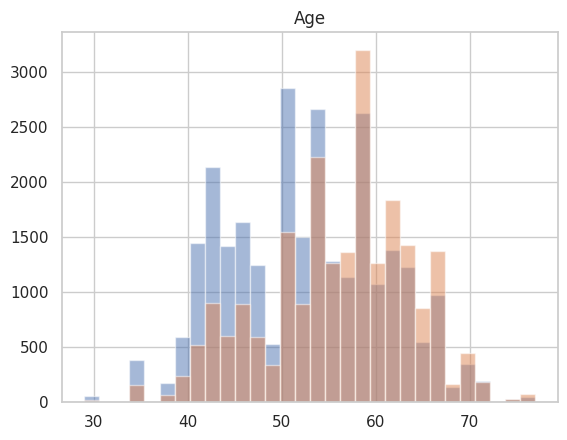

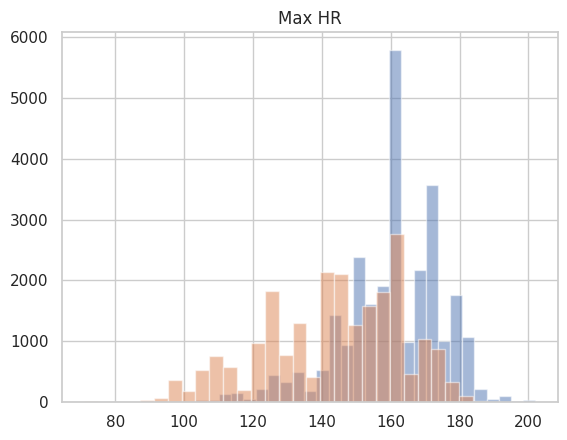

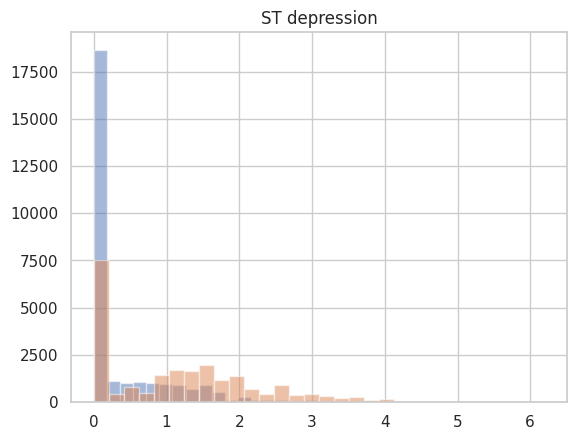

In [13]:
# Numeric: target-wise hist (sampled for speed)
cols = ["Age", "Max HR", "ST depression"]
tmp = train.sample(50_000, random_state=42).assign(y=y)

for c in cols:
    plt.figure()
    tmp[tmp["y"] == 0][c].hist(alpha=0.5, bins=30)
    tmp[tmp["y"] == 1][c].hist(alpha=0.5, bins=30)
    plt.title(c)
    plt.show()


/tmp/ipykernel_17/1538933057.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("x")["y"]


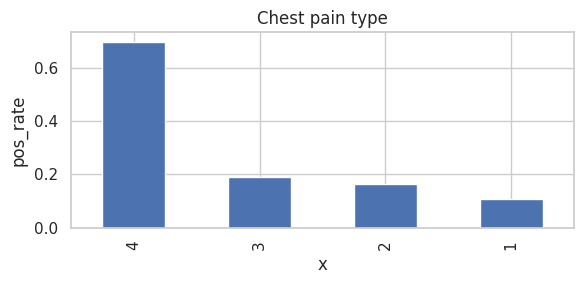

/tmp/ipykernel_17/1538933057.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("x")["y"]


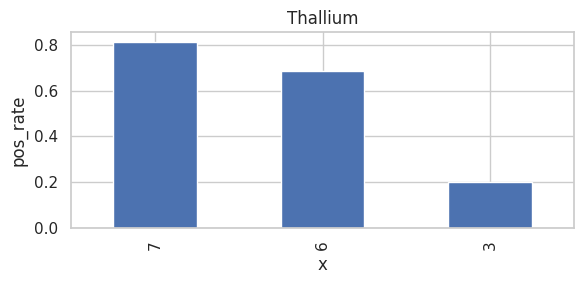

/tmp/ipykernel_17/1538933057.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tmp.groupby("x")["y"]


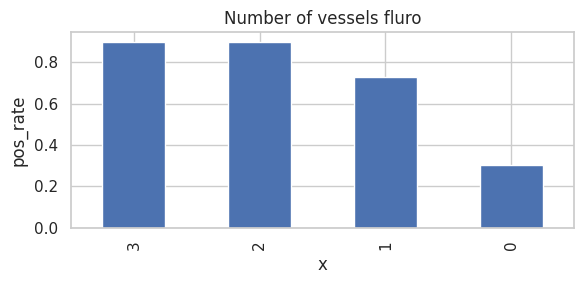

In [14]:
# Categorical: pos_rate by category
cat_plot_cols = ["Chest pain type", "Thallium", "Number of vessels fluro"]

for c in cat_plot_cols:
    if c not in train.columns:
        continue
    df = pos_rate_by_category(c)
    plt.figure(figsize=(6, 3))
    df["pos_rate"].plot(kind="bar")
    plt.title(c)
    plt.ylabel("pos_rate")
    plt.tight_layout()
    plt.show()


### Train vs Test distribution drift

- Adversarial validation (CatBoost, train-vs-test AUC)
- Categorical: rate differences


In [15]:
from catboost import CatBoostClassifier, CatBoostError
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

use_gpu = True

adv_cols = [c for c in FEATURE_COLS if c in test.columns]
adv_cat_cols = [c for c in adv_cols if train[c].nunique(dropna=True) <= 20]

X_adv = pd.concat([
    train[adv_cols].assign(_is_test=0),
    test[adv_cols].assign(_is_test=1),
], axis=0).reset_index(drop=True)
y_adv = X_adv.pop("_is_test")

X_adv_train, X_adv_valid, y_adv_train, y_adv_valid = train_test_split(
    X_adv,
    y_adv,
    test_size=0.2,
    random_state=42,
    stratify=y_adv,
)

adv_cat_idx = [X_adv_train.columns.get_loc(c) for c in adv_cat_cols if c in X_adv_train.columns]

adv_params = dict(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=3000,
    od_type="Iter",
    od_wait=150,
    depth=5,
    learning_rate=0.08,
    random_seed=42,
    verbose=200,
)
if use_gpu:
    adv_params.update(task_type="GPU", devices="0")
else:
    adv_params.update(task_type="CPU")

adv_model = CatBoostClassifier(**adv_params)

try:
    adv_model.fit(
        X_adv_train,
        y_adv_train,
        cat_features=adv_cat_idx,
        eval_set=(X_adv_valid, y_adv_valid),
        use_best_model=True,
    )
except CatBoostError:
    # GPU can be unavailable on some environments; keep a CPU fallback.
    cpu_params = {k: v for k, v in adv_params.items() if k not in ["task_type", "devices"]}
    cpu_params["task_type"] = "CPU"
    adv_model = CatBoostClassifier(**cpu_params)
    adv_model.fit(
        X_adv_train,
        y_adv_train,
        cat_features=adv_cat_idx,
        eval_set=(X_adv_valid, y_adv_valid),
        use_best_model=True,
    )

adv_valid_pred = adv_model.predict_proba(X_adv_valid)[:, 1]
adv_auc = roc_auc_score(y_adv_valid, adv_valid_pred)
print(f"Adversarial validation AUC (train vs test): {adv_auc:.4f}")

imp = adv_model.get_feature_importance()
drift_num = (
    pd.DataFrame(
        {
            "col": adv_model.feature_names_,
            "adversarial_importance": imp,
        }
    )
    .sort_values("adversarial_importance", ascending=False)
    .reset_index(drop=True)
)
drift_num.head(20)


0:	test: 0.5016309	best: 0.5016309 (0)	total: 622ms	remaining: 31m 4s
200:	test: 0.5030310	best: 0.5040084 (161)	total: 1m 18s	remaining: 18m 16s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.5040083868
bestIteration = 161

Shrink model to first 162 iterations.
Adversarial validation AUC (train vs test): 0.5040


,col,adversarial_importance
0,BP,11.990563
1,Age,11.974533
2,Cholesterol,10.684169
3,ST depression,10.602732
4,Slope of ST,9.271983
5,Max HR,9.090587
6,Number of vessels fluro,7.538423
7,Thallium,6.762891
8,Chest pain type,5.878862
9,EKG results,5.552453


### Categorical rate differences

In [16]:
cat_cols = [c for c in FEATURE_COLS if c in test.columns and train[c].nunique(dropna=True) <= 20]

rows = []
for c in cat_cols:
    train_rate = train[c].value_counts(normalize=True)
    test_rate = test[c].value_counts(normalize=True)
    diff = (train_rate - test_rate).abs().fillna(0).sum() / 2
    rows.append((c, diff))

drift_cat = pd.DataFrame(rows, columns=["col", "total_variation_distance"]).sort_values(
    "total_variation_distance", ascending=False
)
drift_cat.head(20)


,col,total_variation_distance
5,Slope of ST,0.003089
6,Number of vessels fluro,0.002210
1,Chest pain type,0.002090
3,EKG results,0.001618
0,Sex,0.001580
4,Exercise angina,0.000930
7,Thallium,0.000311
2,FBS over 120,0.000065


In [17]:
from catboost import CatBoostClassifier, CatBoostError
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
import numpy as np
import pandas as pd

use_gpu = bool(globals().get("use_gpu", True))

# --- categorical columns: fix them explicitly ---
cat_cols_model = [
    "Sex",
    "FBS over 120",
    "Exercise angina",
    "EKG results",
    "Slope of ST",
    "Thallium",
    "Number of vessels fluro",
    "Chest pain type",
]

feature_cols = [c for c in train.columns if c not in [target_col, ID_COL]]

X_train_full = train[feature_cols].copy()
X_test = test[feature_cols].copy()

# make categorical columns string (avoid pandas category dtype issues)
for c in cat_cols_model:
    X_train_full[c] = X_train_full[c].astype(str)
    X_test[c] = X_test[c].astype(str)

cat_idx = [X_train_full.columns.get_loc(c) for c in cat_cols_model]

X_model = X_train_full
X_test_model = X_test

def run_catboost_cv(X, y, train_params, n_splits=5, cat_features=None, tag="cv"):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    rows = []

    cat_idx = None
    if cat_features:
        cat_idx = [X.columns.get_loc(c) for c in cat_features if c in X.columns]

    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), start=1):
        print(f"===== {tag} fold {fold}/{n_splits} =====")
        X_tr, X_va = X.iloc[tr_idx], X.iloc[va_idx]
        y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

        fold_model = CatBoostClassifier(**train_params)
        try:
            fold_model.fit(
                X_tr,
                y_tr,
                cat_features=cat_idx,
                eval_set=(X_va, y_va),
                use_best_model=True,
            )
        except CatBoostError:
            print("[WARN] GPU failed -> fallback to CPU")
            cpu_params = {k: v for k, v in train_params.items() if k not in ["task_type", "devices"]}
            cpu_params["task_type"] = "CPU"
            fold_model = CatBoostClassifier(**cpu_params)
            fold_model.fit(
                X_tr,
                y_tr,
                cat_features=cat_idx,
                eval_set=(X_va, y_va),
                use_best_model=True,
            )

        va_pred = fold_model.predict_proba(X_va)[:, 1]
        auc = roc_auc_score(y_va, va_pred)
        best_it = fold_model.get_best_iteration()
        if best_it is None or best_it < 1:
            best_it = train_params.get("iterations", 1000)
        print(f"[{tag} fold {fold}] AUC={auc:.6f}  best_iteration={best_it}")

        rows.append({"fold": fold, "roc_auc": auc, "best_iteration": int(best_it)})

    cv_table = pd.DataFrame(rows)
    best_it_median = int(np.median(cv_table["best_iteration"]))
    final_iterations = max(1, int(best_it_median * 1.15))

    cv_stats = {
        "mean_roc_auc": float(cv_table["roc_auc"].mean()),
        "std_roc_auc": float(cv_table["roc_auc"].std(ddof=1)),
        "mean_best_iteration": float(cv_table["best_iteration"].mean()),
        "best_it_median": best_it_median,
        "final_iterations": final_iterations,
    }
    return cv_table, cv_stats

train_params = dict(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=3000,
    od_type="Iter",
    od_wait=150,
    depth=5,
    learning_rate=0.08,
    random_seed=42,
    verbose=100,
)
if use_gpu:
    train_params.update(task_type="GPU", devices="0")
else:
    train_params.update(task_type="CPU")

cv_table, cv_stats = run_catboost_cv(
    X_model,
    y,
    train_params,
    n_splits=5,
    cat_features=cat_cols_model,
    tag="base",
)

best_it_median = cv_stats["best_it_median"]
final_iterations = cv_stats["final_iterations"]

print(
    f"base CV mean AUC={cv_stats['mean_roc_auc']:.6f} +/- {cv_stats['std_roc_auc']:.6f}, "
    f"best_it_median={best_it_median}, final_iterations={final_iterations}"
)
cv_table


===== base fold 1/5 =====
[WARN] GPU failed -> fallback to CPU
0:	test: 0.9175143	best: 0.9175143 (0)	total: 399ms	remaining: 19m 58s
100:	test: 0.9546186	best: 0.9546186 (100)	total: 29.5s	remaining: 14m 6s
200:	test: 0.9551089	best: 0.9551089 (200)	total: 1m	remaining: 14m
300:	test: 0.9554512	best: 0.9554512 (300)	total: 1m 31s	remaining: 13m 39s
400:	test: 0.9556297	best: 0.9556297 (400)	total: 2m 2s	remaining: 13m 11s
500:	test: 0.9557222	best: 0.9557222 (500)	total: 2m 33s	remaining: 12m 46s
600:	test: 0.9557781	best: 0.9557781 (600)	total: 3m 5s	remaining: 12m 18s
700:	test: 0.9558015	best: 0.9558044 (683)	total: 3m 37s	remaining: 11m 53s
800:	test: 0.9558299	best: 0.9558300 (796)	total: 4m 10s	remaining: 11m 26s
900:	test: 0.9558335	best: 0.9558374 (886)	total: 4m 42s	remaining: 10m 59s
1000:	test: 0.9558450	best: 0.9558450 (1000)	total: 5m 16s	remaining: 10m 31s
1100:	test: 0.9558510	best: 0.9558523 (1067)	total: 5m 49s	remaining: 10m 2s
1200:	test: 0.9558503	best: 0.9558535 (

,fold,roc_auc,best_iteration
0,1,0.955854,1192
1,2,0.954802,968
2,3,0.955622,993
3,4,0.955161,1091
4,5,0.956051,1367


In [18]:
summary = pd.DataFrame(
    {
        "metric": [
            "mean_roc_auc",
            "std_roc_auc",
            "mean_best_iteration",
            "best_it_median",
            "final_iterations",
        ],
        "value": [
            cv_stats["mean_roc_auc"],
            cv_stats["std_roc_auc"],
            cv_stats["mean_best_iteration"],
            cv_stats["best_it_median"],
            cv_stats["final_iterations"],
        ],
    }
)
summary


,metric,value
0,mean_roc_auc,0.955498
1,std_roc_auc,0.000511
2,mean_best_iteration,1122.200000
3,best_it_median,1091.000000
4,final_iterations,1254.000000


### Fast tuning setup (3-fold + shorter early stopping)

In [19]:
train_params_fast = dict(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=1500,
    od_type="Iter",
    od_wait=50,
    depth=5,
    learning_rate=0.12,
    rsm=0.8,
    bootstrap_type="Bernoulli",
    subsample=0.85,
    random_seed=42,
    task_type="CPU",
    verbose=200,
)

fast_cv_table, fast_cv_stats = run_catboost_cv(
    X_model,
    y,
    train_params_fast,
    n_splits=3,
    cat_features=cat_cols_model,
    tag="fast",
)

pd.DataFrame(
    {
        "metric": [
            "mean_roc_auc",
            "std_roc_auc",
            "best_it_median",
            "final_iterations",
        ],
        "value": [
            fast_cv_stats["mean_roc_auc"],
            fast_cv_stats["std_roc_auc"],
            fast_cv_stats["best_it_median"],
            fast_cv_stats["final_iterations"],
        ],
    }
)


===== fast fold 1/3 =====
0:	test: 0.9163122	best: 0.9163122 (0)	total: 425ms	remaining: 10m 37s
200:	test: 0.9549911	best: 0.9549911 (200)	total: 52.2s	remaining: 5m 37s
400:	test: 0.9553044	best: 0.9553062 (399)	total: 1m 47s	remaining: 4m 53s
600:	test: 0.9553469	best: 0.9553534 (555)	total: 2m 42s	remaining: 4m 2s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9553533934
bestIteration = 555

Shrink model to first 556 iterations.
[fast fold 1] AUC=0.955353  best_iteration=555
===== fast fold 2/3 =====
0:	test: 0.9168123	best: 0.9168123 (0)	total: 377ms	remaining: 9m 24s
200:	test: 0.9548213	best: 0.9548213 (200)	total: 51.8s	remaining: 5m 34s
400:	test: 0.9551054	best: 0.9551054 (400)	total: 1m 45s	remaining: 4m 48s
600:	test: 0.9551665	best: 0.9551677 (598)	total: 2m 40s	remaining: 3m 59s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9551807608
bestIteration = 627

Shrink model to first 628 iterations.
[fast fold 2] AUC=0.955181  best_iter

,metric,value
0,mean_roc_auc,0.955389
1,std_roc_auc,0.000228
2,best_it_median,598.000000
3,final_iterations,687.000000


### Priority B/C lightweight parameter sweeps

In [20]:
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import pandas as pd

# Option A: fast holdout sweep (single split)
X_sw_tr, X_sw_va, y_sw_tr, y_sw_va = train_test_split(
    X_model,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

cat_idx_sw = [X_model.columns.get_loc(c) for c in cat_cols_model if c in X_model.columns]

def run_catboost_holdout(train_params, tag="holdout"):
    model = CatBoostClassifier(**train_params)
    try:
        model.fit(
            X_sw_tr,
            y_sw_tr,
            cat_features=cat_idx_sw,
            eval_set=(X_sw_va, y_sw_va),
            use_best_model=True,
        )
    except CatBoostError:
        cpu_params = {k: v for k, v in train_params.items() if k not in ["task_type", "devices"]}
        cpu_params["task_type"] = "CPU"
        model = CatBoostClassifier(**cpu_params)
        model.fit(
            X_sw_tr,
            y_sw_tr,
            cat_features=cat_idx_sw,
            eval_set=(X_sw_va, y_sw_va),
            use_best_model=True,
        )

    va_pred = model.predict_proba(X_sw_va)[:, 1]
    auc = roc_auc_score(y_sw_va, va_pred)
    best_it = model.get_best_iteration()
    if best_it is None or best_it < 1:
        best_it = train_params.get("iterations", 1000)

    return {
        "mean_roc_auc": float(auc),
        "std_roc_auc": 0.0,
        "best_it_median": int(best_it),
        "final_iterations": max(1, int(best_it * 1.15)),
        "tag": tag,
    }

# Priority B: depth x l2_leaf_reg (fast holdout)
search_rows = []
for depth in [4, 5, 6]:
    for l2_leaf_reg in [1, 3, 5, 10]:
        params = train_params_fast.copy()
        params.update(depth=depth, l2_leaf_reg=l2_leaf_reg)
        stats = run_catboost_holdout(params, tag=f"d{depth}_l2{l2_leaf_reg}")
        search_rows.append(
            {
                "phase": "holdout",
                "depth": depth,
                "l2_leaf_reg": l2_leaf_reg,
                "mean_roc_auc": stats["mean_roc_auc"],
                "std_roc_auc": stats["std_roc_auc"],
                "best_it_median": stats["best_it_median"],
                "final_iterations": stats["final_iterations"],
            }
        )

# Priority C: random_strength / bagging_temperature (fast holdout)
for random_strength in [0.0, 1.0, 2.0]:
    for bagging_temperature in [0.0, 0.5, 1.0]:
        params = train_params_fast.copy()
        params.update(
            bootstrap_type="Bayesian",
            random_strength=random_strength,
            bagging_temperature=bagging_temperature,
        )
        params.pop("subsample", None)
        stats = run_catboost_holdout(params, tag=f"rs{random_strength}_bt{bagging_temperature}")
        search_rows.append(
            {
                "phase": "holdout",
                "random_strength": random_strength,
                "bagging_temperature": bagging_temperature,
                "mean_roc_auc": stats["mean_roc_auc"],
                "std_roc_auc": stats["std_roc_auc"],
                "best_it_median": stats["best_it_median"],
                "final_iterations": stats["final_iterations"],
            }
        )

sweep_holdout = pd.DataFrame(search_rows).sort_values("mean_roc_auc", ascending=False).reset_index(drop=True)
sweep_holdout.head(12)

# Option B: re-check top candidates with lighter 3-fold CV
top_checks = []
for _, row in sweep_holdout.head(3).iterrows():
    params = train_params_fast.copy()
    params.update(iterations=800, od_wait=30)

    if "depth" in row and pd.notna(row.get("depth")):
        params["depth"] = int(row["depth"])
    if "l2_leaf_reg" in row and pd.notna(row.get("l2_leaf_reg")):
        params["l2_leaf_reg"] = float(row["l2_leaf_reg"])

    if "random_strength" in row and pd.notna(row.get("random_strength")):
        params.update(
            bootstrap_type="Bayesian",
            random_strength=float(row["random_strength"]),
            bagging_temperature=float(row["bagging_temperature"]),
        )
        params.pop("subsample", None)

    _, stats = run_catboost_cv(X_model, y, params, n_splits=3, cat_features=cat_cols_model, tag="top_recheck")
    top_checks.append({
        "mean_roc_auc": stats["mean_roc_auc"],
        "std_roc_auc": stats["std_roc_auc"],
        "best_it_median": stats["best_it_median"],
        "final_iterations": stats["final_iterations"],
        "params": params,
    })

sweep_recheck = pd.DataFrame(top_checks).sort_values(["mean_roc_auc", "std_roc_auc"], ascending=[False, True])
sweep_recheck


0:	test: 0.9055899	best: 0.9055899 (0)	total: 323ms	remaining: 8m 4s
200:	test: 0.9556234	best: 0.9556234 (200)	total: 46.9s	remaining: 5m 2s
400:	test: 0.9560666	best: 0.9560667 (396)	total: 1m 34s	remaining: 4m 19s
600:	test: 0.9562132	best: 0.9562132 (600)	total: 2m 24s	remaining: 3m 35s
800:	test: 0.9562588	best: 0.9562592 (795)	total: 3m 14s	remaining: 2m 49s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9562756845
bestIteration = 878

Shrink model to first 879 iterations.
0:	test: 0.9055899	best: 0.9055899 (0)	total: 294ms	remaining: 7m 20s
200:	test: 0.9555835	best: 0.9555835 (200)	total: 46.5s	remaining: 5m
400:	test: 0.9560697	best: 0.9560697 (400)	total: 1m 34s	remaining: 4m 18s
600:	test: 0.9561854	best: 0.9561861 (596)	total: 2m 23s	remaining: 3m 34s
800:	test: 0.9562392	best: 0.9562425 (771)	total: 3m 13s	remaining: 2m 48s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9562425243
bestIteration = 771

Shrink model to first 772 iter

,mean_roc_auc,std_roc_auc,best_it_median,final_iterations,params
0,0.955446,0.000223,793,911,"{'loss_function': 'Logloss', 'eval_metric': 'A..."
2,0.955440,0.000236,592,680,"{'loss_function': 'Logloss', 'eval_metric': 'A..."
1,0.955431,0.000240,798,917,"{'loss_function': 'Logloss', 'eval_metric': 'A..."


### Submit prediction

In [21]:
from catboost import CatBoostClassifier, CatBoostError
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold

use_gpu = bool(globals().get("use_gpu", True))

TARGET = target_col
ID_COL = "id"

# --- categorical columns: fix them explicitly ---
cat_cols_model = [
    "Sex",
    "FBS over 120",
    "Exercise angina",
    "EKG results",
    "Slope of ST",
    "Thallium",
    "Number of vessels fluro",
    "Chest pain type",
]

feature_cols = [c for c in train.columns if c not in [TARGET, ID_COL]]

X_train_full = train[feature_cols].copy()
X_test = test[feature_cols].copy()

# make categorical columns string (avoid pandas category dtype issues)
for c in cat_cols_model:
    X_train_full[c] = X_train_full[c].astype(str)
    X_test[c] = X_test[c].astype(str)

cat_idx = [X_train_full.columns.get_loc(c) for c in cat_cols_model]

if "final_iterations" not in globals():
    if "cv_table" in globals() and not cv_table.empty:
        best_it_median = int(np.median(cv_table["best_iteration"]))
        final_iterations = max(1, int(best_it_median * 1.15))
    else:
        best_it_median = 1200
        final_iterations = int(best_it_median * 1.15)

final_params = dict(
    loss_function="Logloss",
    eval_metric="AUC",
    iterations=int(final_iterations),
    depth=5,
    learning_rate=0.08,
    random_seed=42,
    verbose=False,
)
if use_gpu:
    final_params.update(task_type="GPU", devices="0")
else:
    final_params.update(task_type="CPU")

cv_submit = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
test_pred = np.zeros(len(X_test))
oof_pred = np.zeros(len(X_train_full))
fold_aucs = []

for fold, (tr_idx, va_idx) in enumerate(cv_submit.split(X_train_full, y), start=1):
    X_tr, X_va = X_train_full.iloc[tr_idx], X_train_full.iloc[va_idx]
    y_tr, y_va = y.iloc[tr_idx], y.iloc[va_idx]

    fold_model = CatBoostClassifier(**final_params)
    try:
        fold_model.fit(X_tr, y_tr, cat_features=cat_idx, verbose=False)
    except CatBoostError:
        cpu_params = {k: v for k, v in final_params.items() if k not in ["task_type", "devices"]}
        cpu_params["task_type"] = "CPU"
        fold_model = CatBoostClassifier(**cpu_params)
        fold_model.fit(X_tr, y_tr, cat_features=cat_idx, verbose=False)

    va_pred = fold_model.predict_proba(X_va)[:, 1]
    oof_pred[va_idx] = va_pred
    fold_auc = roc_auc_score(y_va, va_pred)
    fold_aucs.append(fold_auc)

    test_pred += fold_model.predict_proba(X_test)[:, 1] / cv_submit.n_splits
    print(f"[submit fold {fold}] AUC={fold_auc:.6f}")

submit = sub.copy()
submit["Heart Disease"] = test_pred

if kaggle_dir.exists():
    submit.to_csv("submission.csv", index=False)
else:
    submit.to_csv("../data/submissions/catboost_baseline.csv", index=False)

print(f"Fixed iterations from CV best_iteration median: {final_iterations} (median={best_it_median})")
print(f"OOF AUC: {roc_auc_score(y, oof_pred):.6f}  fold_mean={np.mean(fold_aucs):.6f}")
submit.head()


[submit fold 1] AUC=0.955848
[submit fold 2] AUC=0.954786
[submit fold 3] AUC=0.955617
[submit fold 4] AUC=0.955156
[submit fold 5] AUC=0.956044
Fixed iterations from CV best_iteration median: 1254 (median=1091)
OOF AUC: 0.955489  fold_mean=0.955490


,id,Heart Disease
0,630000,0.953299
1,630001,0.006913
2,630002,0.989277
3,630003,0.004105
4,630004,0.206179
